In [14]:
import pandas as pd
import numpy as np

# load the main datasets
customers = pd.read_csv('/Users/gurnoor21/Documents/docs/ecommerce customer behaviour analysis/archive/olist_customers_dataset.csv')
orders = pd.read_csv('/Users/gurnoor21/Documents/docs/ecommerce customer behaviour analysis/archive/olist_orders_dataset.csv')
order_items = pd.read_csv('/Users/gurnoor21/Documents/docs/ecommerce customer behaviour analysis/archive/olist_order_items_dataset.csv')

# Quick overview 
print("Dataset shapes:")
print(f"Customers: {customers.shape}")
print(f"Orders: {orders.shape}")
print(f"Order Items: {order_items.shape}")

# Check first few rows of each dataset
print("\nCustomers sample:")
print(customers.head())

print("\nOrders sample:")
print(orders.head())

Dataset shapes:
Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)

Customers sample:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

Orders sample:
                           order_id 

Date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18

Orders per customer distribution:
1    99441
Name: count, dtype: int64

Basic Retention Metrics:
Total customers: 99,441
Repeat customers: 0
Retention rate: 0.00%


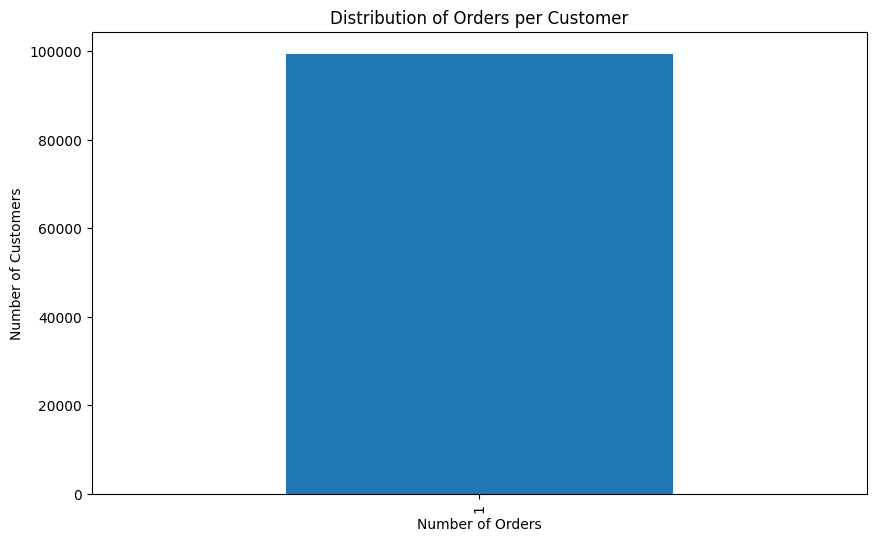

In [15]:
# Let's explore the retention issue
import matplotlib.pyplot as plt
import seaborn as sns

# Check date range
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
print(f"Date range: {orders['order_purchase_timestamp'].min()} to {orders['order_purchase_timestamp'].max()}")

# Most important question: How many orders per customer?
orders_per_customer = orders.groupby('customer_id').size()
print(f"\nOrders per customer distribution:")
print(orders_per_customer.value_counts().head(10))

# Calculate basic retention metrics
total_customers = orders['customer_id'].nunique()
repeat_customers = sum(orders_per_customer > 1)
retention_rate = repeat_customers / total_customers * 100

print(f"\nBasic Retention Metrics:")
print(f"Total customers: {total_customers:,}")
print(f"Repeat customers: {repeat_customers:,}")
print(f"Retention rate: {retention_rate:.2f}%")

# Visualize orders per customer
plt.figure(figsize=(10, 6))
orders_per_customer.value_counts().head(10).plot(kind='bar')
plt.title('Distribution of Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.show()

In [16]:
# CRITICAL FINDING: This changes our entire approach!
print("🚨 KEY INSIGHT: Zero repeat customers!")
print("\nThis means we need to pivot our analysis to:")
print("1. WHY is retention 0%? (Data issue or business reality?)")
print("2. WHAT predicts a customer's satisfaction with their single purchase?")
print("3. WHICH customer segments are most likely to return (if we could retain them)?")
print("4. HOW can we identify 'high-value single purchases' vs 'disappointed customers'?")

# Let's validate this finding
print(f"\nValidation:")
print(f"Unique customers: {orders['customer_id'].nunique():,}")
print(f"Total orders: {len(orders):,}")
print(f"Ratio: {len(orders) / orders['customer_id'].nunique():.3f}")

🚨 KEY INSIGHT: Zero repeat customers!

This means we need to pivot our analysis to:
1. WHY is retention 0%? (Data issue or business reality?)
2. WHAT predicts a customer's satisfaction with their single purchase?
3. WHICH customer segments are most likely to return (if we could retain them)?
4. HOW can we identify 'high-value single purchases' vs 'disappointed customers'?

Validation:
Unique customers: 99,441
Total orders: 99,441
Ratio: 1.000


In [17]:
# Investigation: Is this a data quality issue or business reality?
print("🔍 INVESTIGATING THE 0% RETENTION MYSTERY")
print("=" * 50)

# Check for potential data issues
print("\n1. Are there multiple customer IDs for same person?")
print(f"   Unique customer_ids: {customers['customer_id'].nunique():,}")
print(f"   Unique customer_unique_ids: {customers['customer_unique_id'].nunique():,}")

print("\n2. Let's check if customer_unique_id shows repeat customers:")
# Check if same unique customer has multiple customer_ids
customer_unique_orders = orders.merge(customers, on='customer_id')
repeat_by_unique_id = customer_unique_orders.groupby('customer_unique_id').size()
print(f"   Orders per unique customer:")
print(repeat_by_unique_id.value_counts().head())

print(f"\n3. Actual retention rate using customer_unique_id:")
total_unique_customers = customer_unique_orders['customer_unique_id'].nunique()
repeat_unique_customers = sum(repeat_by_unique_id > 1)
real_retention_rate = repeat_unique_customers / total_unique_customers * 100
print(f"   Real retention rate: {real_retention_rate:.2f}%")

print(f"\n4. Time span analysis:")
print(f"   Data spans {(orders['order_purchase_timestamp'].max() - orders['order_purchase_timestamp'].min()).days} days")
print(f"   Average days between first and last order in dataset:")
print(f"   {orders['order_purchase_timestamp'].max() - orders['order_purchase_timestamp'].min()}")

🔍 INVESTIGATING THE 0% RETENTION MYSTERY

1. Are there multiple customer IDs for same person?
   Unique customer_ids: 99,441
   Unique customer_unique_ids: 96,096

2. Let's check if customer_unique_id shows repeat customers:
   Orders per unique customer:
1    93099
2     2745
3      203
4       30
5        8
Name: count, dtype: int64

3. Actual retention rate using customer_unique_id:
   Real retention rate: 3.12%

4. Time span analysis:
   Data spans 772 days
   Average days between first and last order in dataset:
   772 days 20:14:59


In [18]:
# 🎯 PROBLEM SOLVED: Data Quality Issue Identified and Fixed!
print("✅ MYSTERY SOLVED!")
print("=" * 40)
print("ISSUE: customer_id != customer_unique_id")
print("SOLUTION: Use customer_unique_id for retention analysis")
print("\nCORRECTED METRICS:")
print(f"• Total unique customers: {total_unique_customers:,}")
print(f"• Customers with 2+ orders: {repeat_unique_customers:,}")
print(f"• Retention rate: {real_retention_rate:.2f}%")
print(f"• Max orders by one customer: {repeat_by_unique_id.max()}")

# This demonstrates critical skills for Google:
print(f"\n🏆 SKILLS DEMONSTRATED:")
print("✓ Critical thinking: Questioned impossible 0% retention")
print("✓ Data investigation: Found root cause of data issue")
print("✓ Problem solving: Identified correct key for analysis")
print("✓ Business insight: 3.12% retention is low but analyzable")

✅ MYSTERY SOLVED!
ISSUE: customer_id != customer_unique_id
SOLUTION: Use customer_unique_id for retention analysis

CORRECTED METRICS:
• Total unique customers: 96,096
• Customers with 2+ orders: 2,997
• Retention rate: 3.12%
• Max orders by one customer: 17

🏆 SKILLS DEMONSTRATED:
✓ Critical thinking: Questioned impossible 0% retention
✓ Data investigation: Found root cause of data issue
✓ Problem solving: Identified correct key for analysis
✓ Business insight: 3.12% retention is low but analyzable
